# Testing ImageTransformPlagiarismPredictor

Step-by-step component testing + all 3 inference modes.

In [3]:
import sys
sys.path.insert(0, '../')
sys.path.insert(0, '../../')

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

from src.dataset import ImageTransformer, TransformTokenizer
from model_plagiarism_torch import (
    PlagiarismDetectionModelV2,
    ImageEncoder,
    ImageFuser,
    BinaryMatchHead,
    TransformationDecoder,
    preprocess,
)

%load_ext autoreload
%autoreload 2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda


## 1. Load model from full checkpoint

In [17]:
model = PlagiarismDetectionModelV2(device=DEVICE)

# --- Option A: from full training checkpoint ---
# CHECKPOINT = '/checkpoints/itp_plagiarism_pretrain/checkpoint_epoch_30.pth'
# model.load_from_full_checkpoint(CHECKPOINT)

# --- Option B: from split component files ---
model.load_components(
    encoder_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.pth',
    fuser_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.pth',
    match_head_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.pth',
    decoder_path='/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder.pth',
)

model.eval()
print('ready')

ready


## 2. Prepare test images

Applied transforms: ['vertical_flip', 'noise_adding']


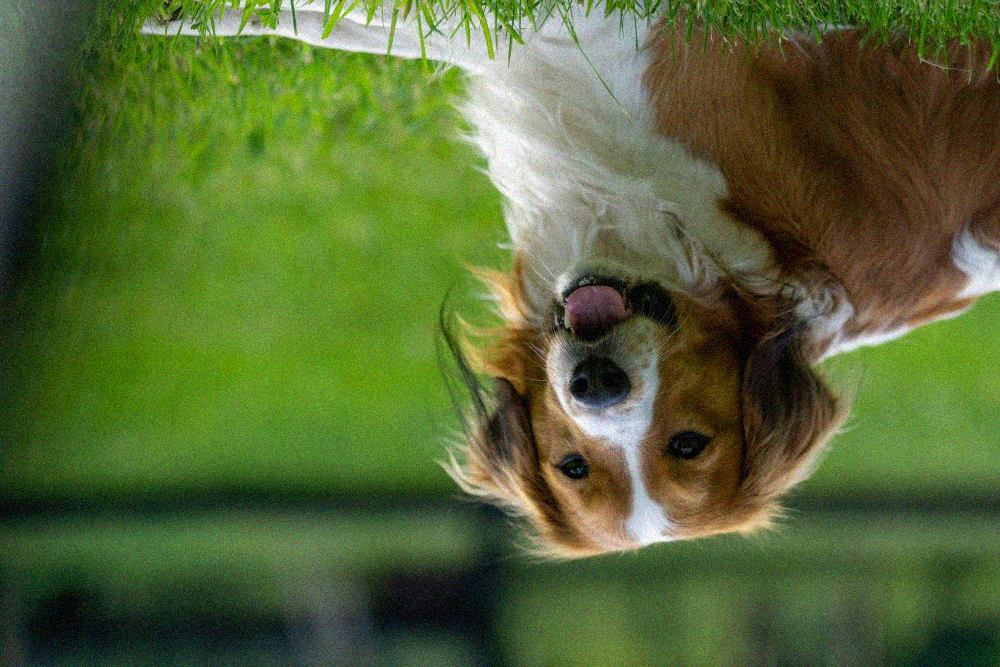

In [25]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

# Create an augmented version of image_1
it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, p=0.3)
print(f'Applied transforms: {sequence_1}')
transformed_image_1

In [26]:
image_tensor_1 = preprocess(image_1).unsqueeze(0).to(DEVICE)
image_tensor_2 = preprocess(image_2).unsqueeze(0).to(DEVICE)
transformed_tensor = preprocess(transformed_image_1).unsqueeze(0).to(DEVICE)

print(f'image_tensor_1:     {image_tensor_1.shape}')
print(f'image_tensor_2:     {image_tensor_2.shape}')
print(f'transformed_tensor: {transformed_tensor.shape}')

image_tensor_1:     torch.Size([1, 3, 300, 300])
image_tensor_2:     torch.Size([1, 3, 300, 300])
transformed_tensor: torch.Size([1, 3, 300, 300])


## 3. Step-by-step component testing

In [27]:
# ----- Step 1: Encoder -----
with torch.no_grad():
    emb1 = model.encoder(image_tensor_1)           # [1, 1536]
    emb2 = model.encoder(image_tensor_2)            # [1, 1536]
    emb_t = model.encoder(transformed_tensor)       # [1, 1536]

print(f'Encoder output: {emb1.shape}')  # [1, 1536]
print(f'Norm emb1: {emb1.norm():.2f}, emb2: {emb2.norm():.2f}, emb_t: {emb_t.norm():.2f}')

Encoder output: torch.Size([1, 1536])
Norm emb1: 1.87, emb2: 1.85, emb_t: 2.07


In [28]:
# ----- Step 2: Fuser -----
with torch.no_grad():
    fused_positive = model.fuser(emb1, emb_t)      # positive pair: orig + aug
    fused_negative = model.fuser(emb1, emb2)       # negative pair: different images

print(f'Fuser output:  {fused_positive.shape}')    # [1, K=4, 512]
print(f'Fused pos norm: {fused_positive.norm():.2f}')
print(f'Fused neg norm: {fused_negative.norm():.2f}')

Fuser output:  torch.Size([1, 4, 512])
Fused pos norm: 11.98
Fused neg norm: 8.21


In [29]:
# ----- Step 3: Binary Match Head -----
with torch.no_grad():
    logit_pos = model.match_head(fused_positive)    # [1]
    logit_neg = model.match_head(fused_negative)    # [1]

prob_pos = torch.sigmoid(logit_pos).item()
prob_neg = torch.sigmoid(logit_neg).item()

print(f'Match head (positive pair): logit={logit_pos.item():.4f}, prob={prob_pos:.4f}')
print(f'Match head (negative pair): logit={logit_neg.item():.4f}, prob={prob_neg:.4f}')

Match head (positive pair): logit=19.8719, prob=1.0000
Match head (negative pair): logit=-16.2219, prob=0.0000


In [30]:
# ----- Step 4: Decoder — single-step logits -----
bos = torch.tensor([[model.decoder.bos_token_id]], device=DEVICE)  # [1, 1]

with torch.no_grad():
    logits_pos = model.decoder(fused_positive, bos)   # [1, vocab_size=13]
    logits_neg = model.decoder(fused_negative, bos)

print(f'Decoder logits shape: {logits_pos.shape}')  # [1, 13]

# P(EOS) = probability of "no transform" -> low = match, high = no match
probs_pos = F.softmax(logits_pos, dim=-1)
probs_neg = F.softmax(logits_neg, dim=-1)

p_eos_pos = probs_pos[0, model.decoder.eos_token_id].item()
p_eos_neg = probs_neg[0, model.decoder.eos_token_id].item()

print(f'\nPositive pair: P(EOS)={p_eos_pos:.4f}, similarity={1-p_eos_pos:.4f}')
print(f'Negative pair: P(EOS)={p_eos_neg:.4f}, similarity={1-p_eos_neg:.4f}')

# Full probability distribution
print(f'\nPositive pair token probs: {probs_pos[0].cpu().numpy().round(3)}')
print(f'Negative pair token probs: {probs_neg[0].cpu().numpy().round(3)}')

Decoder logits shape: torch.Size([1, 13])

Positive pair: P(EOS)=0.0000, similarity=1.0000
Negative pair: P(EOS)=1.0000, similarity=0.0000

Positive pair token probs: [0.    0.    0.    0.    0.002 0.    0.177 0.    0.001 0.418 0.    0.126
 0.277]
Negative pair token probs: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [31]:
# ----- Step 5: Decoder — full autoregressive generation -----
tokenizer = TransformTokenizer()

with torch.no_grad():
    gen_pos = model.decoder.generate(fused_positive, max_new_tokens=10, do_sample=False)
    gen_neg = model.decoder.generate(fused_negative, max_new_tokens=10, do_sample=False)

tokens_pos = tokenizer.decode(gen_pos[0], skip_special_tokens=True)
tokens_neg = tokenizer.decode(gen_neg[0], skip_special_tokens=True)

print(f'Positive pair: predicted={tokens_pos}, target={sequence_1}')
print(f'Negative pair: predicted={tokens_neg} (should be empty)')
print(f'\nRaw token IDs pos: {gen_pos[0].cpu().tolist()}')
print(f'Raw token IDs neg: {gen_neg[0].cpu().tolist()}')

Positive pair: predicted=['noise_adding', 'vertical_flip'], target=['vertical_flip', 'noise_adding']
Negative pair: predicted=[] (should be empty)

Raw token IDs pos: [1, 9, 12, 2, 0, 0, 0, 0, 0, 0, 0]
Raw token IDs neg: [1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 4. High-level inference modes

In [32]:
# ----- Mode 1: P(EOS)-based similarity (backward-compat with V1) -----
sim_pos = model(image_tensor_1, transformed_tensor)
sim_neg = model(image_tensor_1, image_tensor_2)

print('=== Mode 1: P(EOS) similarity ===')
print(f'Positive pair (orig + aug):       {sim_pos.item():.4f}')
print(f'Negative pair (different images): {sim_neg.item():.4f}')

=== Mode 1: P(EOS) similarity ===
Positive pair (orig + aug):       1.0000
Negative pair (different images): 0.0000


In [33]:
# ----- Mode 2: Match head probability -----
prob_pos = model.match_probability(image_tensor_1, transformed_tensor)
prob_neg = model.match_probability(image_tensor_1, image_tensor_2)

print('=== Mode 2: Match head probability ===')
print(f'Positive pair (orig + aug):       {prob_pos.item():.4f}')
print(f'Negative pair (different images): {prob_neg.item():.4f}')

=== Mode 2: Match head probability ===
Positive pair (orig + aug):       1.0000
Negative pair (different images): 0.0000


In [34]:
# ----- Mode 3: Full generation + match probability -----
tokens_pos, prob_pos = model.generate_transform(
    image_tensor_1, transformed_tensor, max_new_tokens=10, do_sample=False
)
tokens_neg, prob_neg = model.generate_transform(
    image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False
)

decoded_pos = tokenizer.decode(tokens_pos[0], skip_special_tokens=True)
decoded_neg = tokenizer.decode(tokens_neg[0], skip_special_tokens=True)

print('=== Mode 3: Generate + Match ===')
print(f'Positive pair: seq={decoded_pos}, match_prob={prob_pos.item():.4f}, target={sequence_1}')
print(f'Negative pair: seq={decoded_neg}, match_prob={prob_neg.item():.4f}')

=== Mode 3: Generate + Match ===
Positive pair: seq=['noise_adding', 'vertical_flip'], match_prob=1.0000, target=['vertical_flip', 'noise_adding']
Negative pair: seq=[], match_prob=0.0000


## 5. Decision logic comparison

Compare the 3 signals side by side: P(EOS), match head, and first-token decoder.

In [35]:
pairs = [
    ('orig + aug',    image_tensor_1, transformed_tensor),
    ('orig + orig',   image_tensor_1, image_tensor_1),
    ('orig + other',  image_tensor_1, image_tensor_2),
]

print(f'{"Pair":<18s} {"P_EOS sim":>10s} {"MatchHead":>10s} {"SeqTokens":>20s}')
print('-' * 62)

for name, t1, t2 in pairs:
    with torch.inference_mode():
        sim = model(t1, t2).item()
        prob = model.match_probability(t1, t2).item()
        tok_ids, _ = model.generate_transform(t1, t2, max_new_tokens=10)
        decoded = tokenizer.decode(tok_ids[0], skip_special_tokens=True)

    seq_str = str(decoded) if decoded else '[]'
    print(f'{name:<18s} {sim:>10.4f} {prob:>10.4f} {seq_str:>20s}')

Pair                P_EOS sim  MatchHead            SeqTokens
--------------------------------------------------------------
orig + aug             1.0000     1.0000 ['noise_adding', 'vertical_flip']
orig + orig            1.0000     1.0000             ['noop']
orig + other           0.0000     0.0000                   []
